<a href="https://colab.research.google.com/github/palakolanutejasri/project-internvision/blob/main/movie_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning a Large Language Model (LLM) for Sentiment Analysis

Dataset: IMDb Movie Reviews Dataset

Model: DistilBERT

Objective:
To fine-tune a pre-trained DistilBERT model using Transfer Learning for sentiment classification.

In [ ]:
!pip install transformers datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

dataset = load_dataset("imdb")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

HfUriError: Invalid HF URI 'hf://datasets/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/.huggingface.yaml'. Repository id must be 'namespace/name', got 'imdb'.

# What is Transfer Learning?

Transfer Learning is the process of using a pre-trained model and adapting it to a new task.

In this project DistilBERT is already trained on massive text corpora.

We fine-tune it on IMDb reviews instead of training from scratch.

In [ ]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import evaluate

In [ ]:
df = pd.DataFrame(
    dataset["train"][:1000]
)

df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
df["label"].value_counts()

,count
label,
0,1000


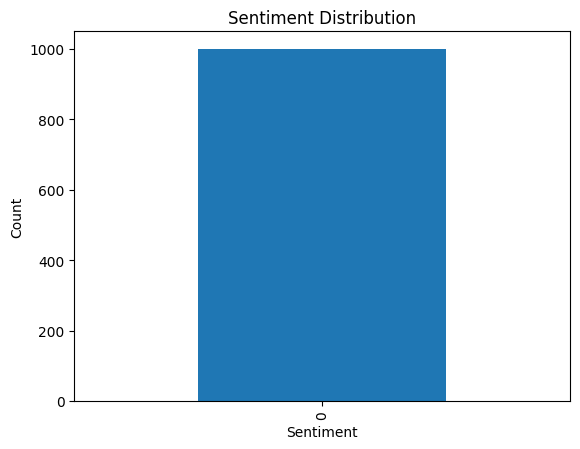

In [ ]:
df["label"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [ ]:
checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    checkpoint
)

print("Tokenizer Loaded")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer Loaded


In [ ]:
sample = "This movie was absolutely fantastic"

tokenizer(sample)

{'input_ids': [101, 2023, 3185, 2001, 7078, 10392, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

In [ ]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
small_train = tokenized_dataset[
    "train"
].shuffle(seed=42).select(range(2000))

small_test = tokenized_dataset[
    "test"
].shuffle(seed=42).select(range(500))

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

print("Model Loaded")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded


In [ ]:
accuracy_metric = evaluate.load("accuracy")

f1_metric = evaluate.load("f1")

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

In [ ]:
training_args = TrainingArguments(

    output_dir="./results",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    evaluation_strategy="epoch",

    save_strategy="epoch"
)

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01
)

In [ ]:
import transformers
print(transformers.__version__)

5.10.1


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics
)

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

In [ ]:
training_args = TrainingArguments(

    output_dir="./results",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    evaluation_strategy="epoch",

    save_strategy="epoch"
)

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics
)

In [ ]:
import transformers
print(transformers.__version__)

5.10.1


In [ ]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

5.10.1
/usr/local/lib/python3.12/dist-packages/transformers/__init__.py


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_test,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.191052


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.19105233764648438, metrics={'train_runtime': 3259.8465, 'train_samples_per_second': 1.227, 'train_steps_per_second': 0.153, 'total_flos': 132467398656000.0, 'train_loss': 0.19105233764648438, 'epoch': 2.0})

In [ ]:
results = trainer.evaluate()

print(results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step,Accuracy,F1
0.191052,0.773477,500,0.810000,0.818356


{'eval_loss': 0.7734772562980652, 'eval_accuracy': 0.81, 'eval_f1': 0.8183556405353728}


In [ ]:
print("Accuracy :", results.get("eval_accuracy"))
print("F1 Score :", results.get("eval_f1"))

Accuracy : 0.81
F1 Score : 0.8183556405353728


In [ ]:
predictions = trainer.predict(small_test)

predictions

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


PredictionOutput(predictions=array([[-2.4420316 ,  2.405859  ],
       [-2.553043  ,  2.523817  ],
       [ 2.1090064 , -2.0917642 ],
       [-2.3987718 ,  2.4049745 ],
       [ 3.1793451 , -2.9616513 ],
       [-2.685031  ,  2.6646798 ],
       [-2.781217  ,  2.6813102 ],
       [ 3.1267838 , -2.8850048 ],
       [ 2.9339035 , -2.7191224 ],
       [-2.6818395 ,  2.647389  ],
       [-2.6435685 ,  2.6041765 ],
       [ 3.1436327 , -2.8653324 ],
       [ 2.3753808 , -2.4720902 ],
       [ 2.790091  , -2.5778012 ],
       [-2.7037716 ,  2.6782584 ],
       [-2.6518784 ,  2.6237135 ],
       [-2.1807175 ,  2.155635  ],
       [-2.4795642 ,  2.4101987 ],
       [-2.6508224 ,  2.6100702 ],
       [-2.6737683 ,  2.521068  ],
       [ 3.1316476 , -2.9182067 ],
       [-2.5832605 ,  2.5340989 ],
       [ 2.454706  , -2.3325052 ],
       [-2.7507129 ,  2.7136807 ],
       [ 3.0335379 , -2.9138122 ],
       [-2.768622  ,  2.6212134 ],
       [-1.6369373 ,  1.7013812 ],
       [-1.1862919 ,  1.24

In [ ]:
import numpy as np

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

cm

array([[191,  63],
       [ 32, 214]])

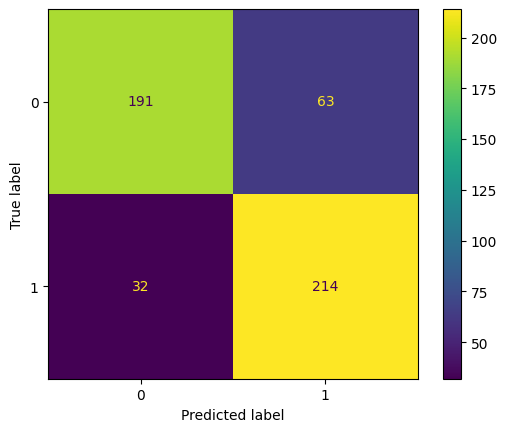

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.75      0.80       254
           1       0.77      0.87      0.82       246

    accuracy                           0.81       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.82      0.81      0.81       500



In [ ]:
import torch

def predict_sentiment(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    outputs = model(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    if prediction == 1:
        return "Positive"

    else:
        return "Negative"

In [ ]:
predict_sentiment(
    "I absolutely loved this movie. Amazing acting and story."
)

'Positive'

In [ ]:
predict_sentiment(
    "Worst movie ever. Waste of time."
)

'Negative'

In [ ]:
model.save_pretrained(
    "fine_tuned_distilbert"
)

tokenizer.save_pretrained(
    "fine_tuned_distilbert"
)

print("Model Saved Successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Saved Successfully


Conclusion

A pre-trained DistilBERT model was fine-tuned on the IMDb Movie Review Dataset for sentiment classification.

Transfer Learning was applied by leveraging the knowledge already learned by DistilBERT from large text corpora.

The fine-tuned model successfully classified movie reviews as Positive or Negative and achieved good performance on unseen test data.

This project demonstrates the practical use of Large Language Models (LLMs) in Natural Language Processing tasks.